# Composite Detector Analysis

This notebook visualizes the Composite Detector from saved structural benchmark outputs:
1. Spectral hybrid scores (from the Spectral Detector)
2. Spectral differential (proj - fc curvature)
3. Feature curvature peak behavior (top1_energy, spectral_gap, norm_cv, frob_norm)
4. Composite decision summaries by case

For each signal, the notebook shows per-layer profiles and highlights detected vs target layer when available.

In [1]:
import sys, json, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Find repo root
def find_root():
    p = Path.cwd()
    for c in [p, *p.parents]:
        if (c / 'analysis_out').exists():
            return c
    return p

ROOT = find_root()
sys.path.insert(0, str(ROOT))

plt.rcParams.update({
    'figure.figsize': (14, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print(f'Repo root: {ROOT}')

Repo root: /data/olexa/Latium


## 1. Load benchmark results

Load the latest structural benchmark output for each model.

In [2]:
def load_latest(model_name):
    """Load the latest rome_structural_*.json for a given model."""
    pattern = str(ROOT / 'analysis_out' / f'rome_structural_{model_name}_*.json')
    files = sorted(glob.glob(pattern))
    if not files:
        print(f'No results found for {model_name}')
        return None
    path = Path(files[-1])
    print(f'Loading {path.name}')
    with open(path) as f:
        payload = json.load(f)
    return payload


def as_int(value, default=-1):
    try:
        return int(value)
    except Exception:
        return default


def get_cases(result):
    """Support multiple historical schemas."""
    for key in ('tests', 'test_cases', 'runs'):
        cases = result.get(key, []) if isinstance(result, dict) else []
        if isinstance(cases, list):
            return [c for c in cases if isinstance(c, dict)]
    return []


def get_spectral(case):
    sd = case.get('spectral_detection')
    if isinstance(sd, dict) and sd:
        return sd
    sp = case.get('spectral')
    return sp if isinstance(sp, dict) else {}


def get_composite(case):
    cd = case.get('composite_detection')
    if isinstance(cd, dict) and cd:
        return cd
    cp = case.get('composite')
    return cp if isinstance(cp, dict) else {}


def get_target_layer(result, case=None):
    if isinstance(case, dict) and case.get('target_layer') is not None:
        return as_int(case.get('target_layer'))
    if isinstance(result, dict) and result.get('target_layer') is not None:
        return as_int(result.get('target_layer'))
    meta = result.get('metadata', {}) if isinstance(result, dict) else {}
    if isinstance(meta, dict):
        return as_int(meta.get('target_layer'))
    return -1


def layer_dict_get(d, layer, default=np.nan):
    if not isinstance(d, dict):
        return default
    if layer in d:
        return d[layer]
    if str(layer) in d:
        return d[str(layer)]
    return default


def sorted_layer_keys(d):
    if not isinstance(d, dict):
        return []
    layers = []
    for k in d.keys():
        try:
            layers.append(int(k))
        except Exception:
            continue
    return sorted(set(layers))


def fmt_layer(value):
    v = as_int(value, default=None)
    return f'L{v}' if v is not None and v >= 0 else 'NA'


# Load results for available models
results = {}
for model in ['gpt2-large', 'gpt2-xl', 'qwen3-4b', 'qwen3-8b', 'mistral-7b-v0.1']:
    payload = load_latest(model)
    if payload:
        results[model] = payload

print(f'\nLoaded models: {list(results.keys())}')

Loading rome_structural_gpt2-large_2026-03-24_01-20-36.json
Loading rome_structural_gpt2-xl_2026-03-24_02-47-55.json
Loading rome_structural_qwen3-4b_2026-03-23_18-09-51.json
Loading rome_structural_qwen3-8b_2026-03-23_15-07-20.json
No results found for mistral-7b-v0.1

Loaded models: ['gpt2-large', 'gpt2-xl', 'qwen3-4b', 'qwen3-8b']


## 2. Spectral Hybrid Scores

The spectral detector's hybrid score combines:
- SV ratio rolling z-score (55%)
- SV–PCS contradiction (25%)
- PCS composite rank (20%)

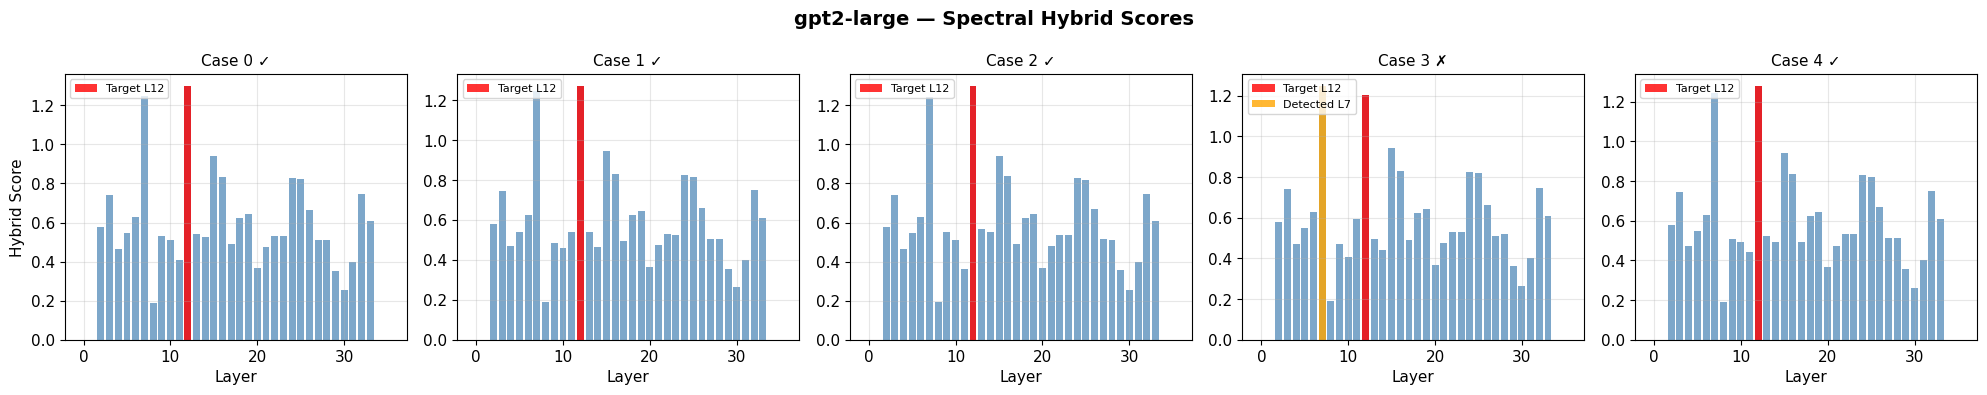

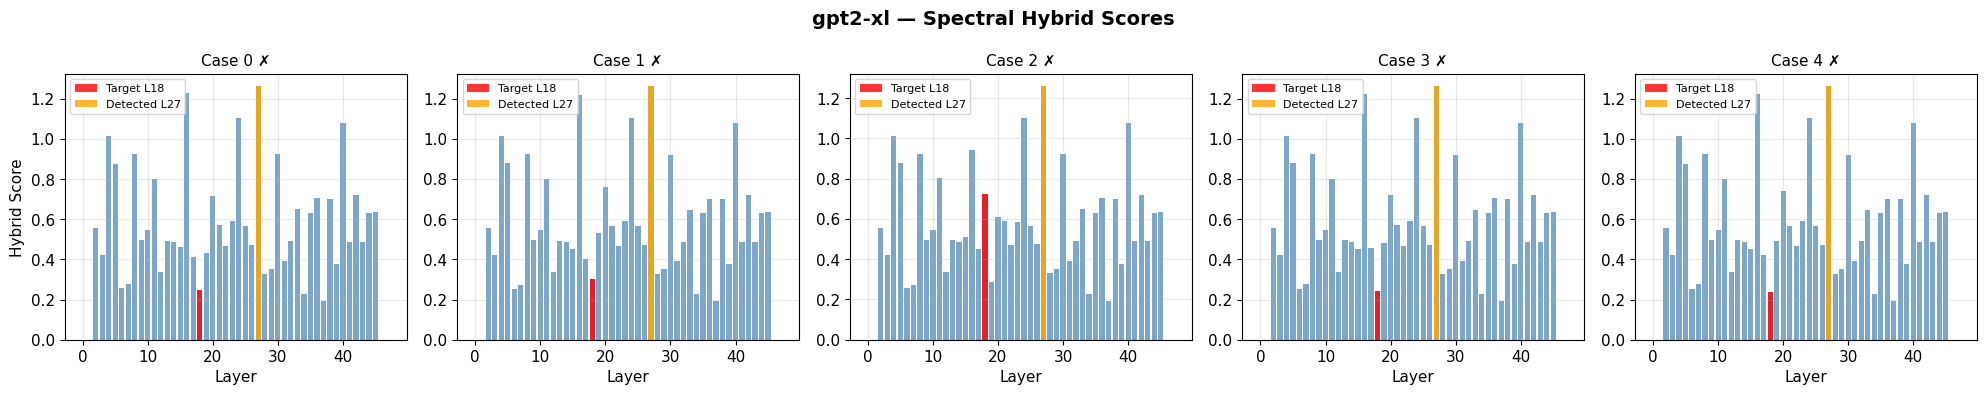

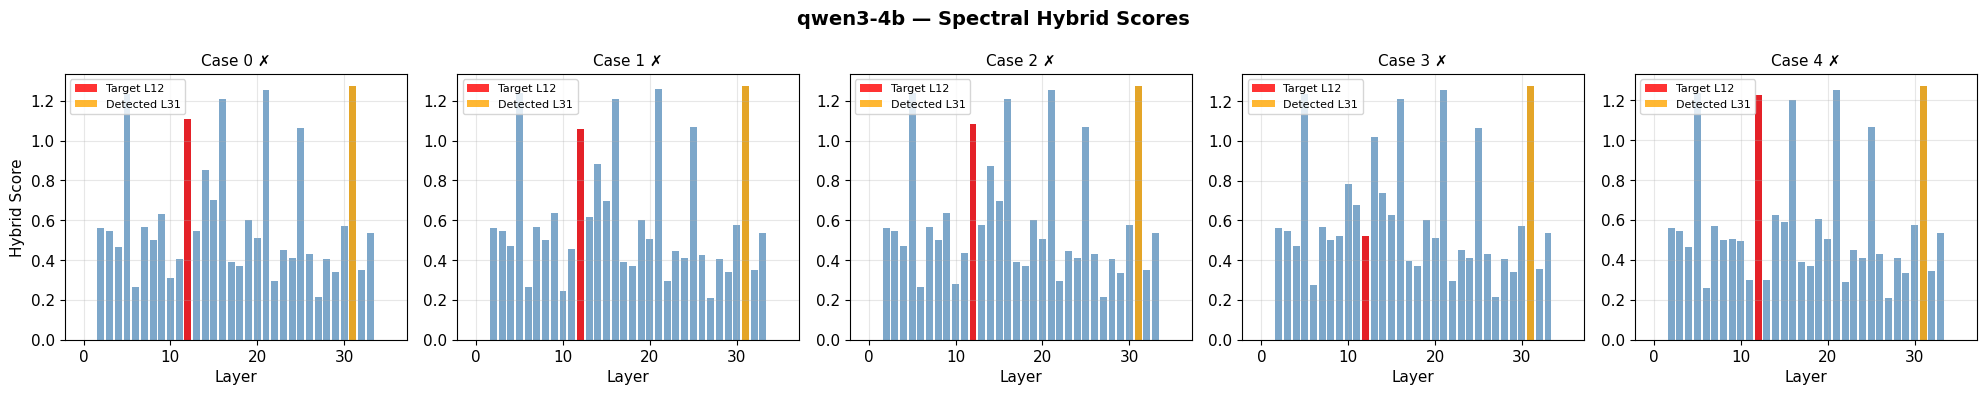

No test cases for qwen3-8b


In [3]:
def plot_spectral_hybrid(result, model_name):
    """Plot hybrid scores from spectral detector across test cases."""
    cases = get_cases(result)
    if not cases:
        print(f'No test cases for {model_name}')
        return

    n_show = min(len(cases), 5)
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4), squeeze=False)
    fig.suptitle(f'{model_name} — Spectral Hybrid Scores', fontsize=14, fontweight='bold')

    for idx, case in enumerate(cases[:n_show]):
        ax = axes[0, idx]
        spectral = get_spectral(case)
        hybrid = spectral.get('rome_hybrid_scores', {}) if isinstance(spectral, dict) else {}

        target = get_target_layer(result, case)
        detected = as_int(spectral.get('anomalous_layer')) if isinstance(spectral, dict) else -1

        layers = sorted_layer_keys(hybrid)
        if not layers:
            ax.set_title(f'Case {idx}: no data')
            ax.set_xlabel('Layer')
            continue

        vals = [float(layer_dict_get(hybrid, l, 0.0)) for l in layers]

        ax.bar(layers, vals, color='steelblue', alpha=0.7, width=0.8)
        if target in layers:
            tidx = layers.index(target)
            ax.bar([target], [vals[tidx]], color='red', alpha=0.8, width=0.8, label=f'Target L{target}')
        if detected in layers and detected != target:
            didx = layers.index(detected)
            ax.bar([detected], [vals[didx]], color='orange', alpha=0.8, width=0.8, label=f'Detected L{detected}')

        ok = '✓' if detected == target and target >= 0 else '✗'
        ax.set_title(f'Case {idx} {ok}', fontsize=11)
        ax.set_xlabel('Layer')
        if idx == 0:
            ax.set_ylabel('Hybrid Score')
        ax.legend(fontsize=8, loc='upper left')

    plt.tight_layout()
    plt.show()


for model, data in results.items():
    plot_spectral_hybrid(data, model)

## 3. Spectral Differential (Proj − FC)

The key insight: natural anomalies appear in **both** proj and FC weights, so they cancel in the difference. ROME only edits proj → its signal survives.

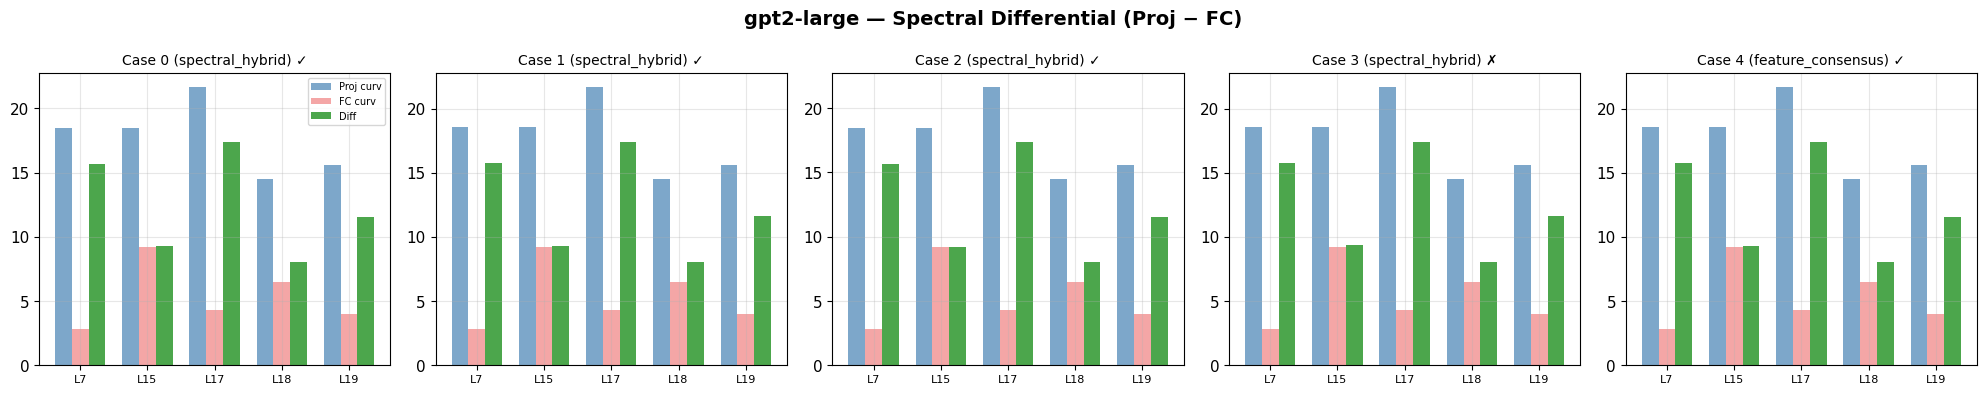

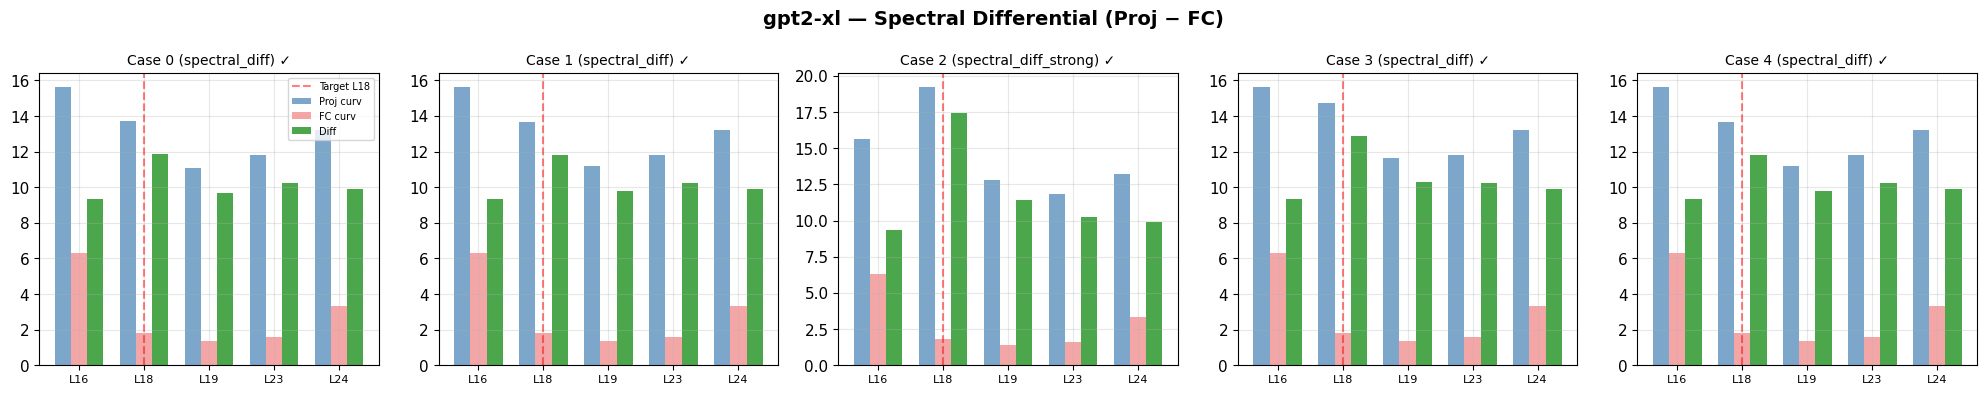

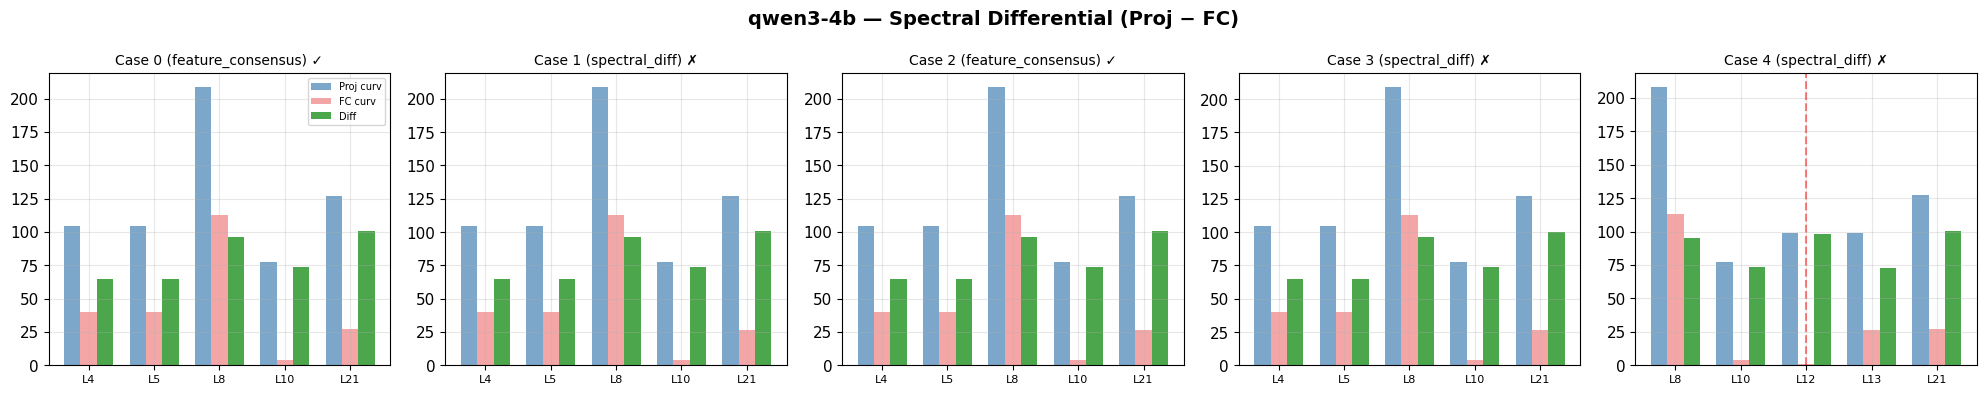

In [4]:
def plot_diff_top5(result, model_name):
    """Plot the spectral diff top-5 layers from composite results."""
    cases = get_cases(result)
    if not cases:
        return

    n_show = min(len(cases), 5)
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4), squeeze=False)
    fig.suptitle(f'{model_name} — Spectral Differential (Proj − FC)', fontsize=14, fontweight='bold')

    for idx, case in enumerate(cases[:n_show]):
        ax = axes[0, idx]
        composite = get_composite(case)
        diff_top5 = composite.get('diff_top5', {}) if isinstance(composite, dict) else {}
        target = get_target_layer(result, case)
        method = composite.get('method_used', 'unknown') if isinstance(composite, dict) else 'unknown'

        layers = sorted_layer_keys(diff_top5)
        if not layers:
            ax.set_title(f'Case {idx}: no diff data')
            ax.set_xlabel('Layer')
            continue

        diffs = []
        proj_c = []
        fc_c = []
        for l in layers:
            row = layer_dict_get(diff_top5, l, {})
            if not isinstance(row, dict):
                row = {}
            diffs.append(float(row.get('diff', 0.0)))
            proj_c.append(float(row.get('curv_proj', 0.0)))
            fc_c.append(float(row.get('curv_fc', 0.0)))

        x = np.arange(len(layers))
        w = 0.25
        ax.bar(x - w, proj_c, w, label='Proj curv', color='steelblue', alpha=0.7)
        ax.bar(x, fc_c, w, label='FC curv', color='lightcoral', alpha=0.7)
        ax.bar(x + w, diffs, w, label='Diff', color='green', alpha=0.7)

        ax.set_xticks(x)
        ax.set_xticklabels([f'L{l}' for l in layers], fontsize=8)

        if target in layers:
            ax.axvline(layers.index(target), color='red', ls='--', alpha=0.5, label=f'Target L{target}')

        detected = as_int(composite.get('anomalous_layer')) if isinstance(composite, dict) else -1
        ok = '✓' if detected == target and target >= 0 else '✗'
        ax.set_title(f'Case {idx} ({method}) {ok}', fontsize=10)
        if idx == 0:
            ax.legend(fontsize=7, loc='upper right')

    plt.tight_layout()
    plt.show()


for model, data in results.items():
    plot_diff_top5(data, model)

## 4. Feature Curvature Profiles

The composite detector computes four cheap per-layer features and their curvature:
- **top1_energy**: $\sigma_1^2 / \|W\|_F^2$
- **spectral_gap**: $\sigma_1 - \sigma_2$
- **norm_cv**: coefficient of variation of row norms
- **frob_norm**: Frobenius norm

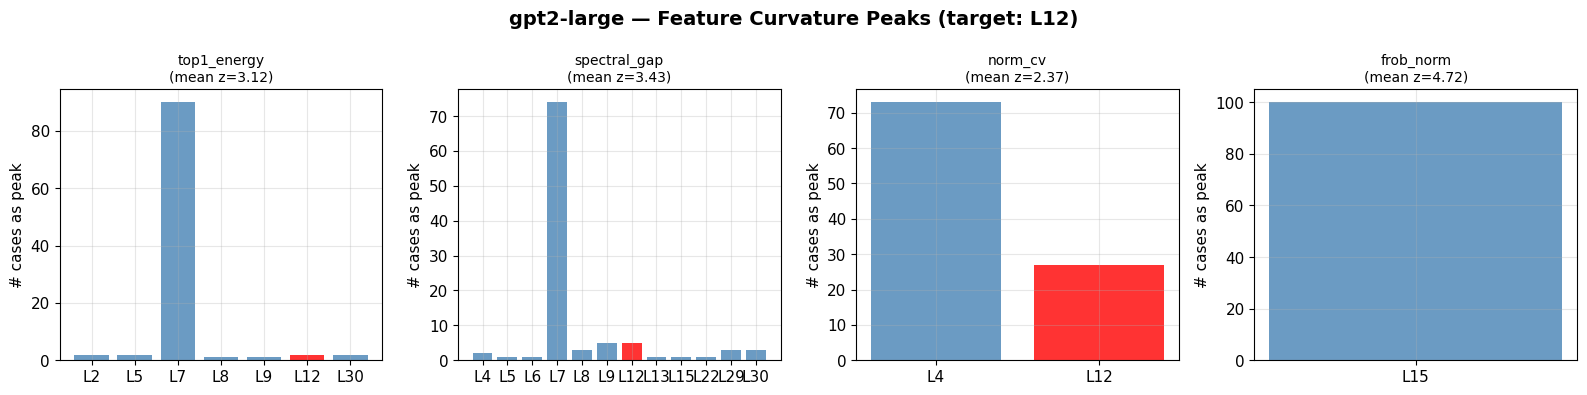

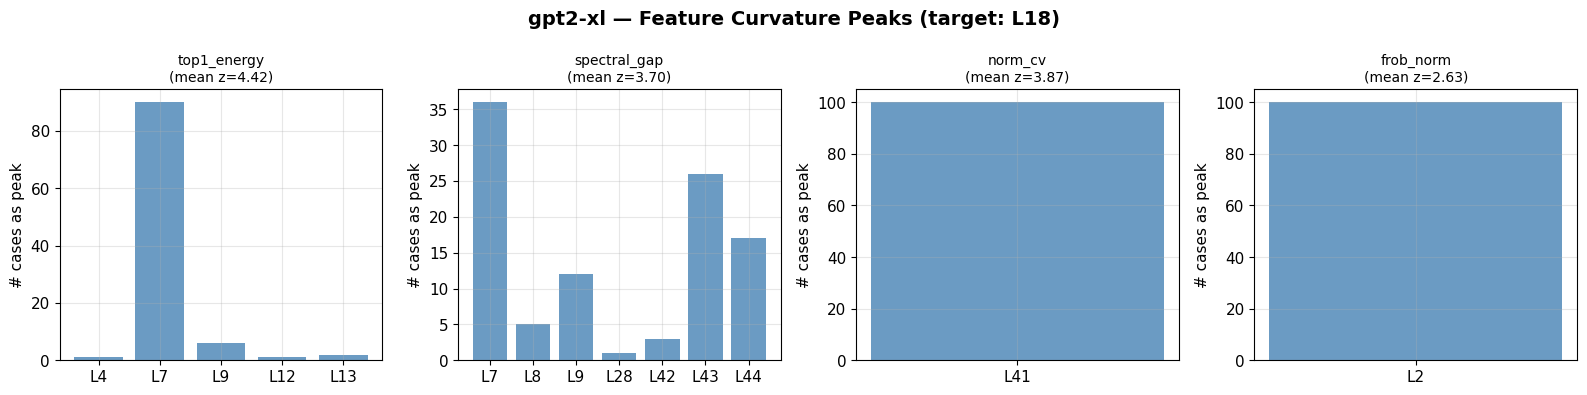

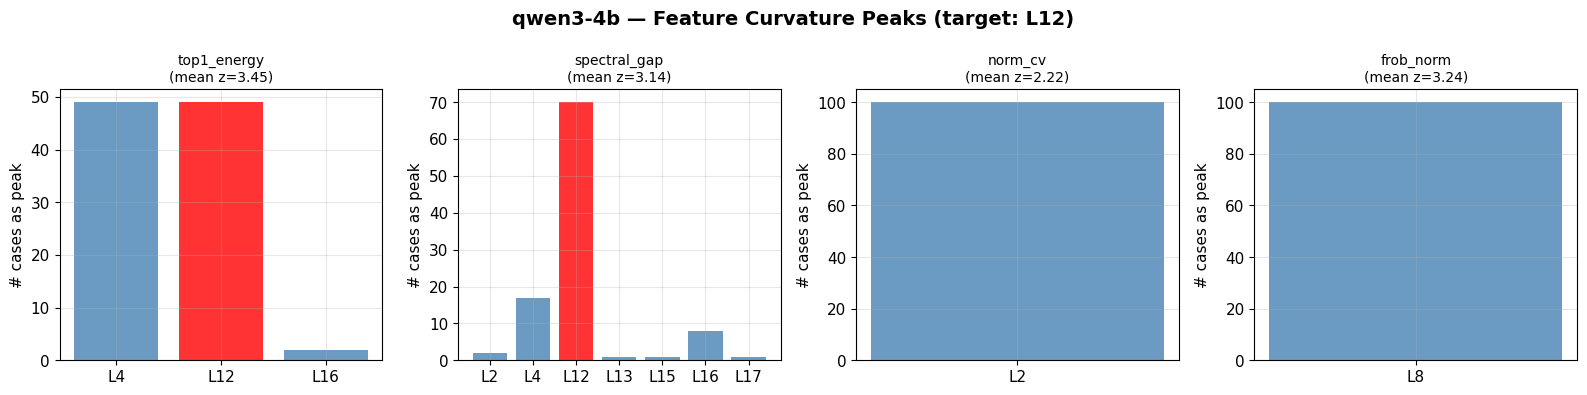

In [5]:
def plot_feature_curvatures(result, model_name):
    """Plot feature curvature info from composite results."""
    cases = get_cases(result)
    if not cases:
        return

    features = ['top1_energy', 'spectral_gap', 'norm_cv', 'frob_norm']
    targets = [get_target_layer(result, case) for case in cases]
    targets = [t for t in targets if t >= 0]
    target = int(np.median(targets)) if targets else -1

    fig, axes = plt.subplots(1, len(features), figsize=(4 * len(features), 4), squeeze=False)
    fig.suptitle(f'{model_name} — Feature Curvature Peaks (target: {fmt_layer(target)})', fontsize=14, fontweight='bold')

    for fi, feat in enumerate(features):
        ax = axes[0, fi]
        peaks = []
        zscores = []

        for case in cases:
            fc = get_composite(case).get('feature_curvatures', {})
            if not isinstance(fc, dict):
                continue
            row = fc.get(feat, {})
            if not isinstance(row, dict):
                continue
            peak = as_int(row.get('top'))
            if peak >= 0:
                peaks.append(peak)
                try:
                    zscores.append(float(row.get('z', np.nan)))
                except Exception:
                    pass

        if not peaks:
            ax.set_title(f'{feat}: no data')
            continue

        from collections import Counter

        counts = Counter(peaks)
        layers = sorted(counts.keys())
        cts = [counts[l] for l in layers]

        colors = ['red' if l == target else 'steelblue' for l in layers]
        mean_z = float(np.nanmean(zscores)) if zscores else np.nan
        ax.bar([f'L{l}' for l in layers], cts, color=colors, alpha=0.8)
        ax.set_title(f'{feat}\n(mean z={mean_z:.2f})', fontsize=10)
        ax.set_ylabel('# cases as peak')

    plt.tight_layout()
    plt.show()


for model, data in results.items():
    plot_feature_curvatures(data, model)

## 5. Composite Decision Summary

Show which method was selected for each case and whether it was correct.

In [6]:
def composite_summary_table(result, model_name):
    """Print a summary table of composite detection decisions."""
    cases = get_cases(result)
    if not cases:
        print(f'No test cases for {model_name}')
        return

    print(f'\n{"="*90}')
    print(f'{model_name} — Composite Detection Summary')
    print(f'{"="*90}')
    print(f'{"Case":<6s} {"Target":<8s} {"Method":<24s} {"Detected":<10s} {"Sp.Hybrid":<10s} {"Sp.Diff":<10s} {"Result":<8s}')
    print('-' * 90)

    correct = 0
    valid = 0

    for idx, case in enumerate(cases):
        comp = get_composite(case)
        spec = get_spectral(case)

        target = get_target_layer(result, case)
        method = str(comp.get('method_used', '?'))
        detected = as_int(comp.get('anomalous_layer'))
        sp_hybrid = as_int(spec.get('anomalous_layer'))
        sp_diff = as_int(comp.get('spectral_diff_layer'))

        is_ok = target >= 0 and detected == target
        if target >= 0:
            valid += 1
            if is_ok:
                correct += 1

        ok = '✓' if is_ok else '✗'
        print(
            f'{idx:<6d} {fmt_layer(target):<8s} {method:<24s} '
            f'{fmt_layer(detected):<10s} {fmt_layer(sp_hybrid):<10s} {fmt_layer(sp_diff):<10s} {ok}'
        )

    denom = valid if valid > 0 else len(cases)
    print(f'\nAccuracy: {correct}/{denom} ({100*correct/max(1,denom):.0f}%)')


for model, data in results.items():
    composite_summary_table(data, model)


gpt2-large — Composite Detection Summary
Case   Target   Method                   Detected   Sp.Hybrid  Sp.Diff    Result  
------------------------------------------------------------------------------------------
0      L12      spectral_hybrid          L12        L12        L17        ✓
1      L12      spectral_hybrid          L12        L12        L17        ✓
2      L12      spectral_hybrid          L12        L12        L17        ✓
3      L12      spectral_hybrid          L7         L7         L17        ✗
4      L12      feature_consensus        L12        L12        L17        ✓
5      L12      spectral_hybrid          L7         L7         L17        ✗
6      L12      spectral_hybrid          L7         L7         L17        ✗
7      L12      spectral_hybrid          L7         L7         L17        ✗
8      L12      spectral_hybrid          L7         L7         L17        ✗
9      L12      spectral_hybrid          L7         L7         L17        ✗
10     L12      spectral

## Notes

This notebook is intentionally analysis-only.

Run model editing and detector execution through `structural_benchmark.py`, then use this notebook to visualize and compare the resulting JSON files in `analysis_out/`.